# Jetson Nano EdgeAI Benchmark — 심층 분석

**6개 모델 × 11개 런타임 × 2개 전력모드 = 132가지 조합**

이 노트북은 단순 성능 비교를 넘어 **왜 이런 결과가 나왔는가**를 AI 아키텍처와 런타임 특성 관점에서 분석한다.

---
## 분석 목차
1. 데이터 로드 및 개요
2. 모델 아키텍처별 분석 — 구조가 성능을 결정한다
3. 런타임별 분석 — 같은 모델, 다른 결과
4. 양자화 효과 — TRT INT8
5. 5W 패러독스 — 전력 절감 ≠ 에너지 절감
6. 정확도 vs 효율 Trade-off
7. 종합 인사이트 — 실제 서비스라면 무엇을 선택할까

In [13]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = r'C:\Windows\Fonts\malgun.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['axes.unicode_minus'] = False
print(f"폰트 설정 완료: {plt.rcParams['font.family']}")

폰트 설정 완료: ['Malgun Gothic']


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# 데이터 로드
df = pd.read_csv('../results/all_results_clean.csv')
df_10w = df[df['power_mode'] == '10w'].copy()
df_5w  = df[df['power_mode'] == '5w'].copy()

print(f'총 실험 수: {len(df)}행 ({len(df_10w)} 10W + {len(df_5w)} 5W)')
print(f'모델: {sorted(df.model.unique())}')
print(f'런타임: {sorted(df.runtime.unique())}')

총 실험 수: 132행 (66 10W + 66 5W)
모델: ['efficientnet_b0', 'mobilenetv3_small', 'resnet50', 'shufflenet_v2_x1_0', 'ssd_mobilenet_v2', 'yolov8n']
런타임: ['ncnn_cpu', 'ncnn_vulkan', 'onnxrt_cuda', 'onnxrt_tensorrt', 'pytorch_cpu', 'pytorch_cuda', 'tensorrt_fp16', 'tensorrt_fp32', 'tensorrt_int8', 'tflite_cpu', 'tflite_gpu']


---
## 1. 데이터 개요

In [15]:
# 모델별 기본 통계 (10W 기준)
summary = df_10w.groupby('model').agg(
    best_latency_ms   = ('latency_mean_ms', 'min'),
    worst_latency_ms  = ('latency_mean_ms', 'max'),
    best_runtime      = ('latency_mean_ms', lambda x: df_10w.loc[x.idxmin(), 'runtime']),
    model_size_mb     = ('model_size_mb', 'first'),
    min_energy_mj     = ('energy_per_inference_mj', lambda x: x[x>0].min()),
).round(2)

print('=== 모델별 성능 요약 (10W) ===')
print(summary.to_string())

=== 모델별 성능 요약 (10W) ===
                    best_latency_ms  worst_latency_ms   best_runtime  model_size_mb  min_energy_mj
model                                                                                             
efficientnet_b0               22.09           1096.30  tensorrt_fp16          20.09          83.81
mobilenetv3_small              6.58            292.57  tensorrt_int8           9.68          18.44
resnet50                      29.82            714.48  tensorrt_fp16          97.39         148.12
shufflenet_v2_x1_0             7.57            321.76  tensorrt_fp16           8.66          22.49
ssd_mobilenet_v2              23.58           1266.68  tensorrt_fp16          23.12          82.80
yolov8n                       53.15            936.03  tensorrt_fp16          12.12         253.98


---
## 2. 모델 아키텍처별 분석

### 모델 구조가 어떻게 추론 속도를 결정하는가?

| 모델 | 아키텍처 특성 | 예상 성능 패턴 |
|------|-------------|---------------|
| MobileNetV3-Small | Inverted Residual + SE module, Hard-swish 활성화 | 가장 빠름, 경량 설계 |
| ShuffleNetV2 x1.0 | Channel Split + Shuffle, 병렬 branch | 빠름, MAC 효율적 |
| EfficientNet-B0 | MBConv + Compound Scaling, Squeeze-Excitation | 중간, 정확도 효율 균형 |
| ResNet-50 | 3×3 Conv 스택 + Skip Connection, 무거운 채널 수 | 느림, 파라미터 많음 |
| SSD-MobileNetV2 | MobileNetV2 backbone + Multi-scale feature map | 중간, 검출 head 추가 |
| YOLOv8n | CSP Bottleneck + Anchor-free head, 640×640 입력 | 입력 크기로 인해 가장 느림 |

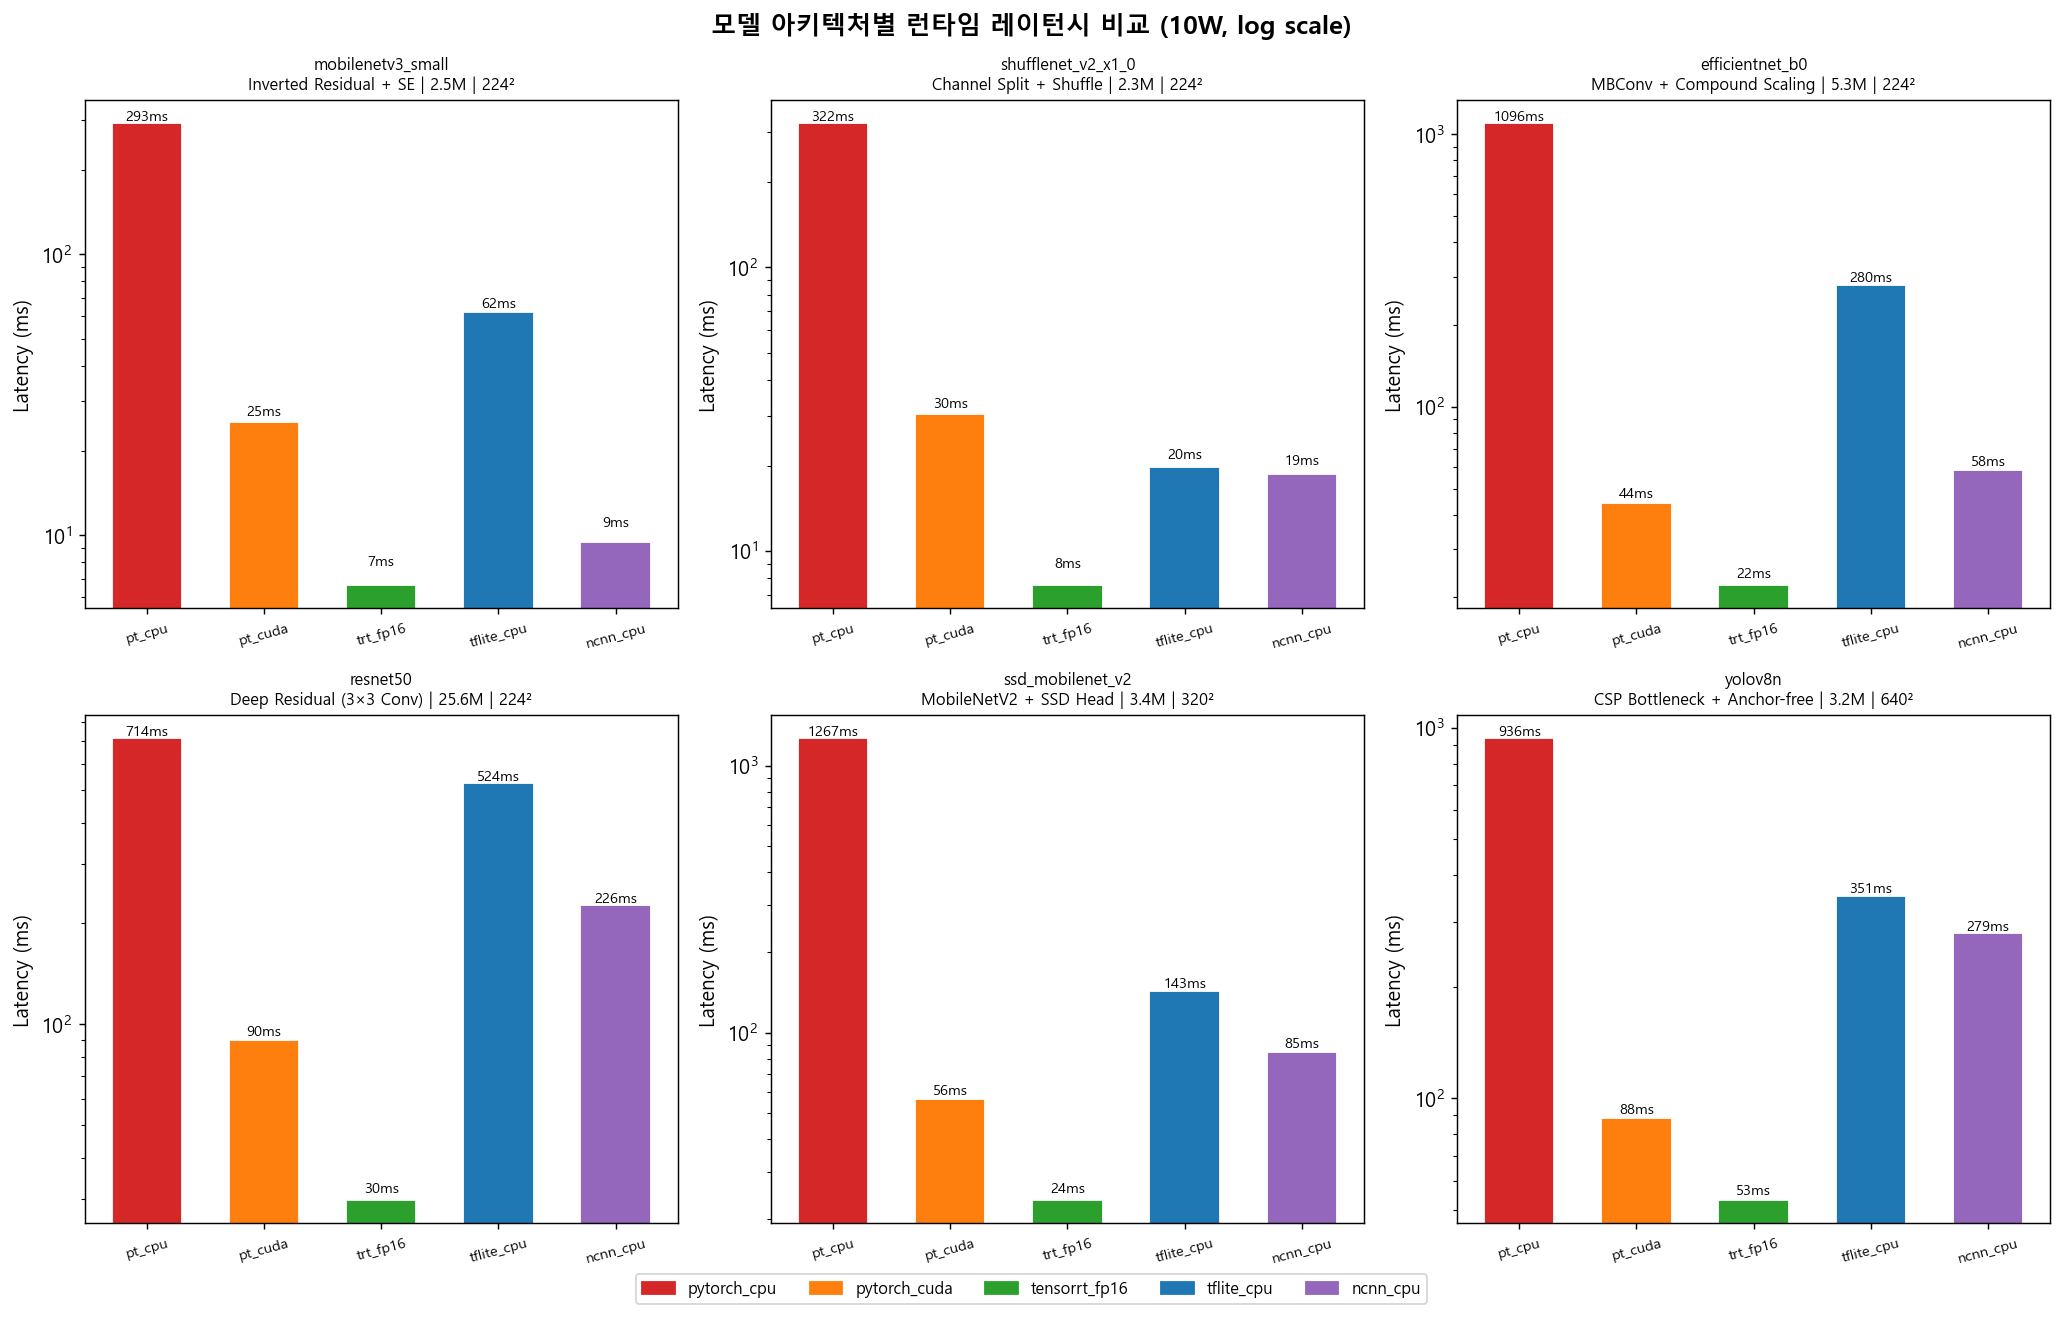

저장: results/arch_latency_comparison.png


In [16]:
# 모델별 최고 런타임 레이턴시 비교 (TRT FP16 기준)
MODEL_INFO = {
    'mobilenetv3_small':    {'params': '2.5M',  'input': '224²', 'type': '분류', 'arch': 'Inverted Residual + SE'},
    'shufflenet_v2_x1_0':  {'params': '2.3M',  'input': '224²', 'type': '분류', 'arch': 'Channel Split + Shuffle'},
    'efficientnet_b0':      {'params': '5.3M',  'input': '224²', 'type': '분류', 'arch': 'MBConv + Compound Scaling'},
    'resnet50':             {'params': '25.6M', 'input': '224²', 'type': '분류', 'arch': 'Deep Residual (3×3 Conv)'},
    'ssd_mobilenet_v2':    {'params': '3.4M',  'input': '320²', 'type': '검출', 'arch': 'MobileNetV2 + SSD Head'},
    'yolov8n':             {'params': '3.2M',  'input': '640²', 'type': '검출', 'arch': 'CSP Bottleneck + Anchor-free'},
}

runtimes_to_compare = ['pytorch_cpu', 'pytorch_cuda', 'tensorrt_fp16', 'tflite_cpu', 'ncnn_cpu']
models_order = ['mobilenetv3_small', 'shufflenet_v2_x1_0', 'efficientnet_b0', 'resnet50', 'ssd_mobilenet_v2', 'yolov8n']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'pytorch_cpu': '#d62728', 'pytorch_cuda': '#ff7f0e', 'tensorrt_fp16': '#2ca02c',
          'tflite_cpu': '#1f77b4', 'ncnn_cpu': '#9467bd'}

for idx, model in enumerate(models_order):
    ax = axes[idx]
    info = MODEL_INFO[model]
    data = df_10w[(df_10w['model'] == model) & (df_10w['runtime'].isin(runtimes_to_compare))]
    data = data.set_index('runtime').reindex(runtimes_to_compare).dropna(subset=['latency_mean_ms'])

    bars = ax.bar(range(len(data)), data['latency_mean_ms'],
                  color=[colors[r] for r in data.index], edgecolor='white', width=0.6)

    for bar, val in zip(bars, data['latency_mean_ms']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}ms', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{model}\n{info["arch"]} | {info["params"]} | {info["input"]}', fontsize=9)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([r.replace('pytorch_', 'pt_').replace('tensorrt_', 'trt_') for r in data.index],
                       fontsize=8, rotation=15)
    ax.set_ylabel('Latency (ms)')
    ax.set_yscale('log')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('모델 아키텍처별 런타임 레이턴시 비교 (10W, log scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/arch_latency_comparison.png', bbox_inches='tight')
plt.show()
print('저장: results/arch_latency_comparison.png')

In [17]:
# 아키텍처 분석 — 핵심 인사이트 출력
print('='*60)
print('모델 아키텍처 → 성능 결과 분석')
print('='*60)

for model in models_order:
    d = df_10w[df_10w['model'] == model]
    best = d.loc[d['latency_mean_ms'].idxmin()]
    worst = d.loc[d['latency_mean_ms'].idxmax()]
    valid = d[d['latency_mean_ms'] > 0]
    cpu = d[d['runtime']=='pytorch_cpu']['latency_mean_ms'].values
    trt = d[d['runtime']=='tensorrt_fp16']['latency_mean_ms'].values
    speedup = f'{cpu[0]/trt[0]:.1f}x' if len(cpu)>0 and len(trt)>0 else 'N/A'
    print(f'\n[{model}]')
    print(f'  최고: {best["runtime"]:20s} {best["latency_mean_ms"]:7.1f} ms')
    print(f'  최저: {worst["runtime"]:20s} {worst["latency_mean_ms"]:7.1f} ms')
    print(f'  TRT FP16 speedup vs PyTorch CPU: {speedup}')

모델 아키텍처 → 성능 결과 분석

[mobilenetv3_small]
  최고: tensorrt_int8            6.6 ms
  최저: pytorch_cpu            292.6 ms
  TRT FP16 speedup vs PyTorch CPU: 44.1x

[shufflenet_v2_x1_0]
  최고: tensorrt_fp16            7.6 ms
  최저: pytorch_cpu            321.8 ms
  TRT FP16 speedup vs PyTorch CPU: 42.5x

[efficientnet_b0]
  최고: tensorrt_fp16           22.1 ms
  최저: pytorch_cpu           1096.3 ms
  TRT FP16 speedup vs PyTorch CPU: 49.6x

[resnet50]
  최고: tensorrt_fp16           29.8 ms
  최저: pytorch_cpu            714.5 ms
  TRT FP16 speedup vs PyTorch CPU: 24.0x

[ssd_mobilenet_v2]
  최고: tensorrt_fp16           23.6 ms
  최저: pytorch_cpu           1266.7 ms
  TRT FP16 speedup vs PyTorch CPU: 53.7x

[yolov8n]
  최고: tensorrt_fp16           53.1 ms
  최저: pytorch_cpu            936.0 ms
  TRT FP16 speedup vs PyTorch CPU: 17.6x


### 아키텍처 분석 해석

**MobileNetV3-Small이 가장 빠른 이유**
- Inverted Residual Block: 채널을 확장했다가 줄이는 구조로 연산량(MAC) 최소화
- Hard-swish 활성화: ReLU 대신 하드웨어 친화적 근사 함수 사용
- SE(Squeeze-Excitation): 채널 중요도를 학습하되 파라미터 수 최소
- 결과: 파라미터 2.5M, 224² 입력에서 가장 낮은 연산량

**ResNet-50이 느린 이유**
- 3×3 Conv를 깊게 쌓는 구조 → 레이어 간 데이터 이동(메모리 대역폭) 비용 큼
- 파라미터 25.6M으로 다른 모델 대비 5~10배 → 가중치 로드 비용
- Skip Connection은 정확도엔 도움이 되지만 추론 그래프를 복잡하게 만듦

**YOLOv8n이 검출 모델 중 느린 이유**
- 입력 해상도 640×640 → 224×224 대비 픽셀 수 8배
- CSP(Cross Stage Partial) Bottleneck: Feature map을 분기-병합하는 구조로 연산 증가
- Anchor-free head: 각 grid cell에서 직접 bbox를 예측 → 출력 텐서 크기 [1, 84, 8400]
- 8400 = 80×80 + 40×40 + 20×20 (3개 스케일 합산)

**SSD-MobileNetV2가 검출 중 빠른 이유**
- MobileNetV2 backbone: 경량화된 특징 추출기
- 320×320 입력: YOLOv8n의 절반 해상도
- Anchor 기반: 미리 정의된 anchor box로 계산량 예측 가능

---
## 2.5 레이어별 심층 분석 — 실제 연산 병목은 어디인가?

아키텍처 수준의 설명에서 한 단계 더 들어가, 각 모델 내부 레이어 단위로 실제 실행 시간을 분석한다.

| 모델 유형 | 프로파일링 방법 | 데이터 |
|----------|--------------|--------|
| 분류 모델 (4개) | PyTorch forward hook | named module별 ms |
| 검출 모델 (2개) | PyTorch autograd.profiler | aten 연산자별 ms |

**분석 목표**
- 어떤 레이어/연산이 전체 추론 시간을 지배하는가?
- 레이어 타입(Conv/BN/ReLU)별 연산 시간 구성이 모델마다 어떻게 다른가?
- TensorRT Layer Fusion이 효과적인 이유를 레이어 수준에서 설명할 수 있는가?

=== 레이어 프로파일링 데이터 로드 ===
mobilenetv3_small              (classification): 141 ops,  합산 65.4 ms
shufflenet_v2_x1_0             (classification): 151 ops,  합산 69.5 ms
efficientnet_b0                (classification): 223 ops,  합산 124.2 ms
resnet50                       (classification): 126 ops,  합산 167.4 ms
ssd_mobilenet_v2               (detection     ):  40 ops,  합산 172.8 ms
yolov8n                        (detection     ):  31 ops,  합산 138.2 ms


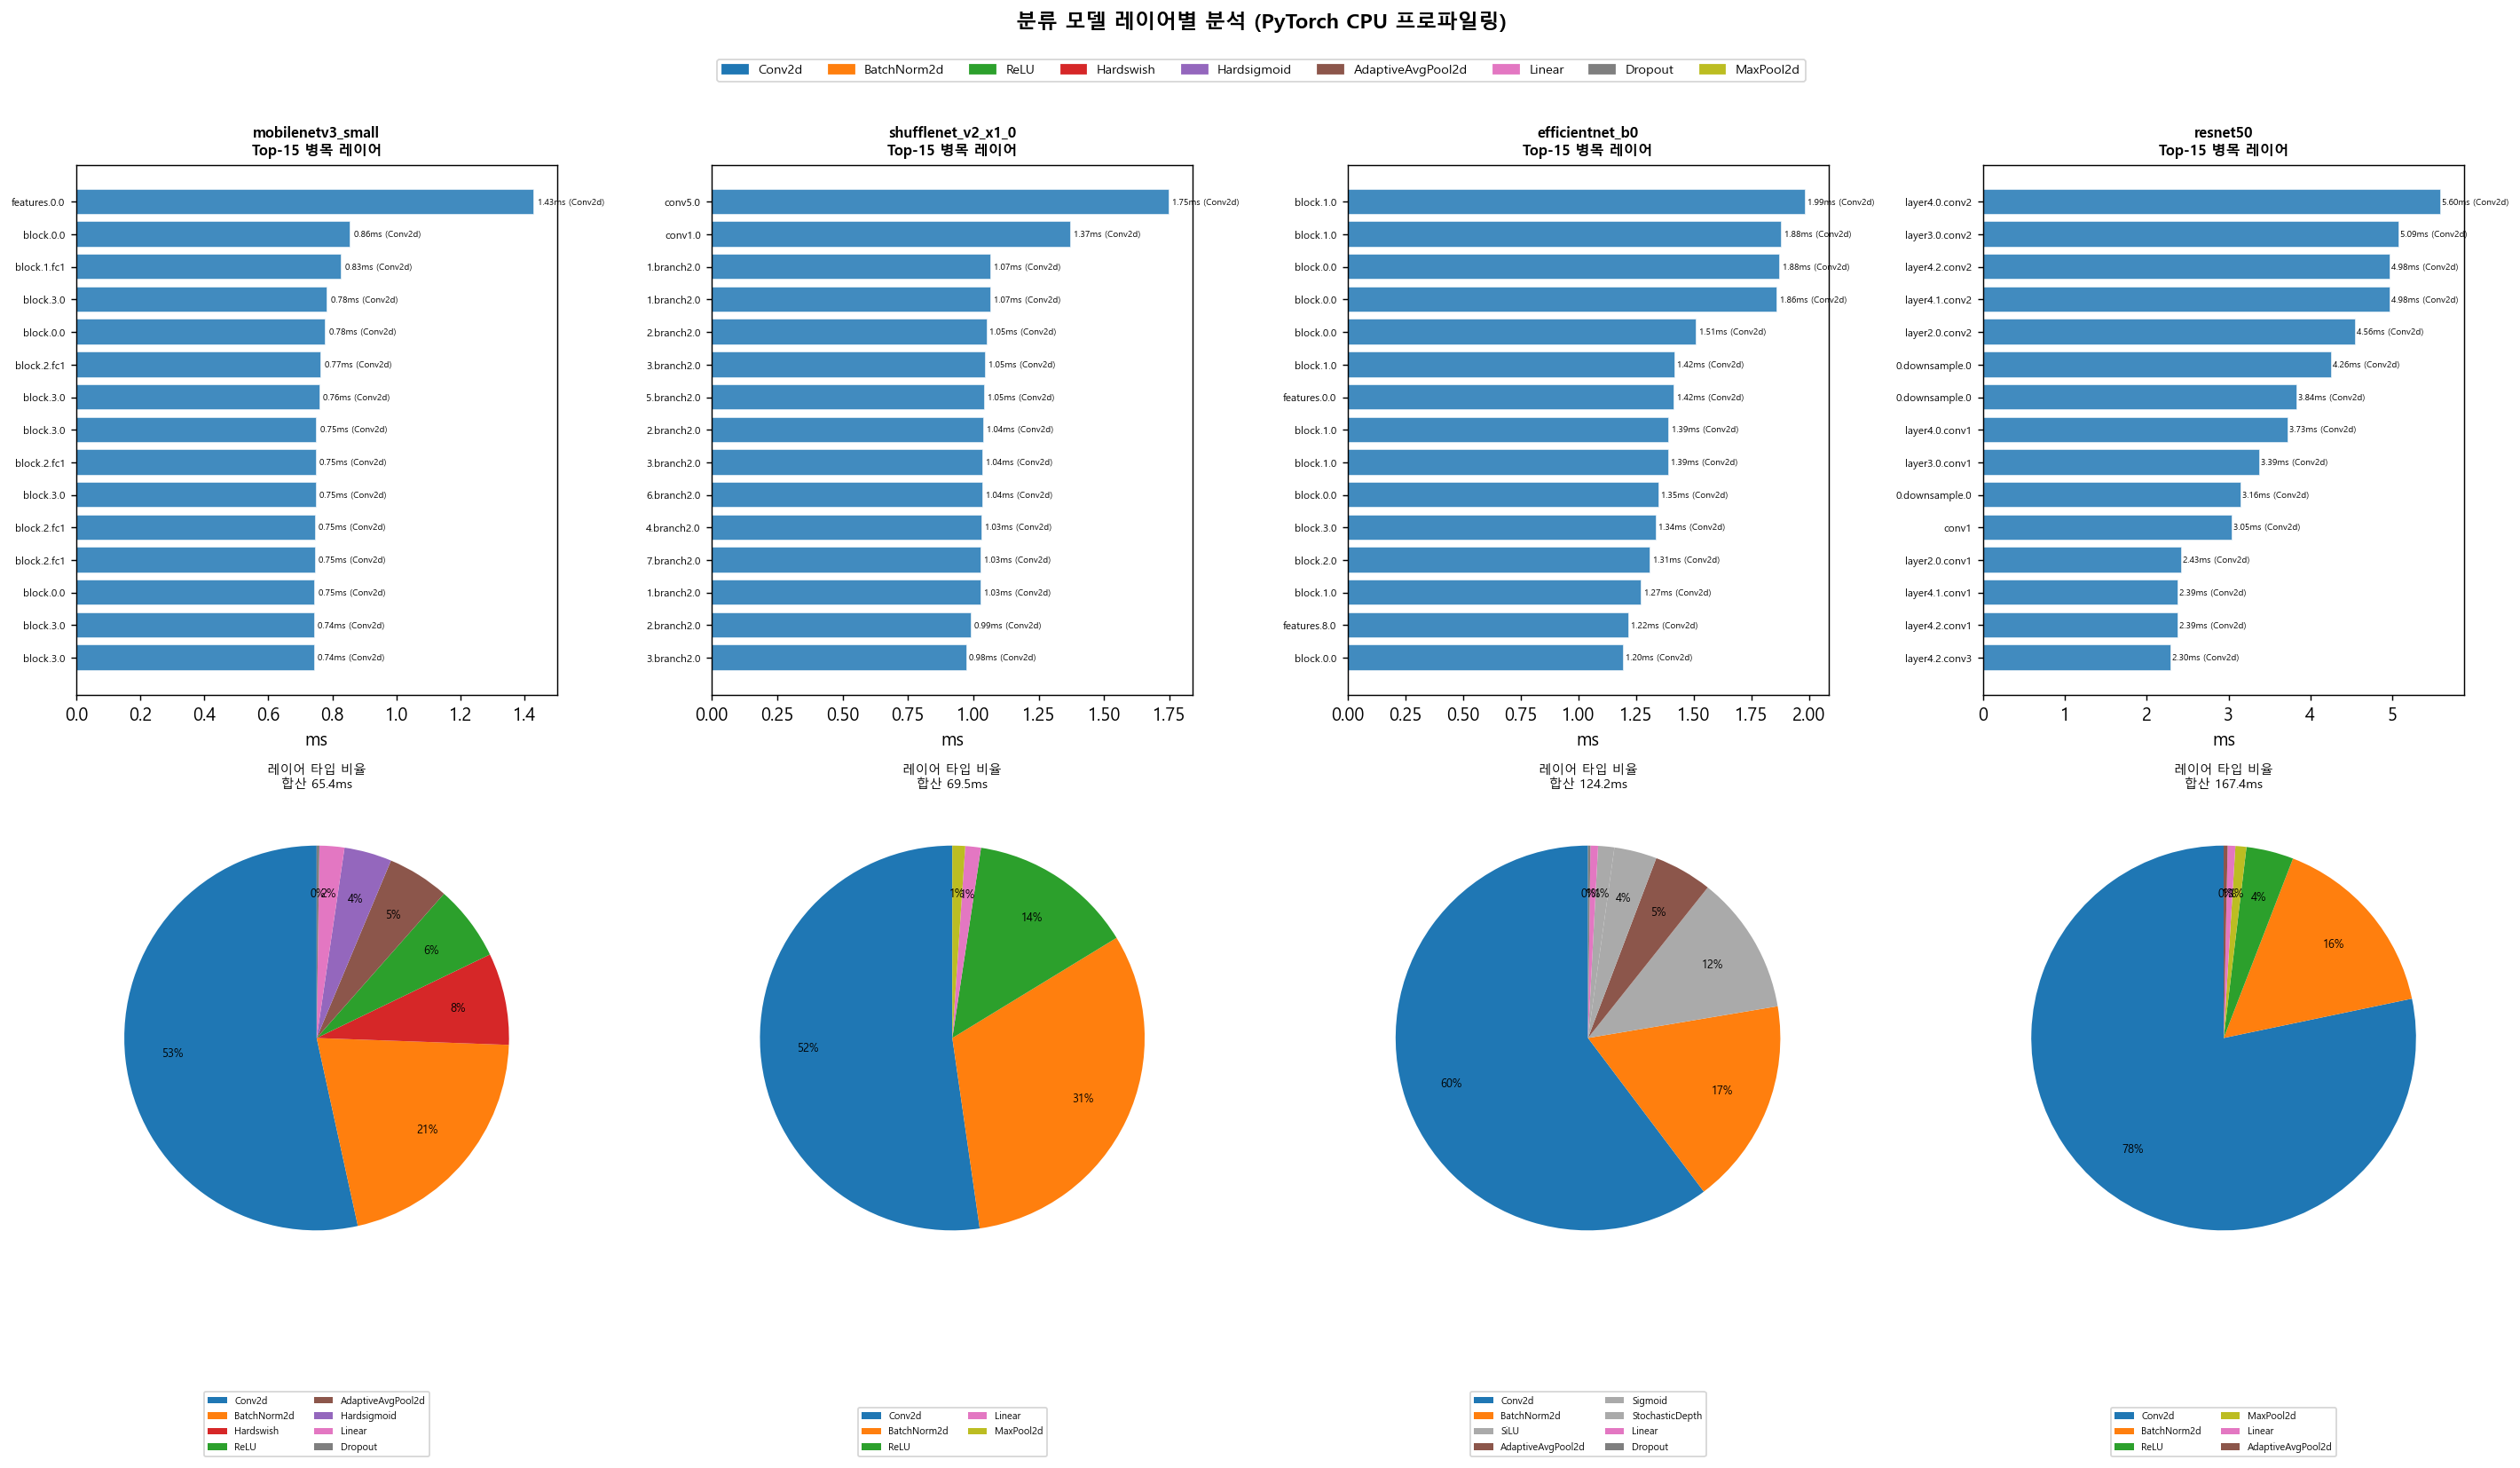

저장: results/clf_layer_analysis.png


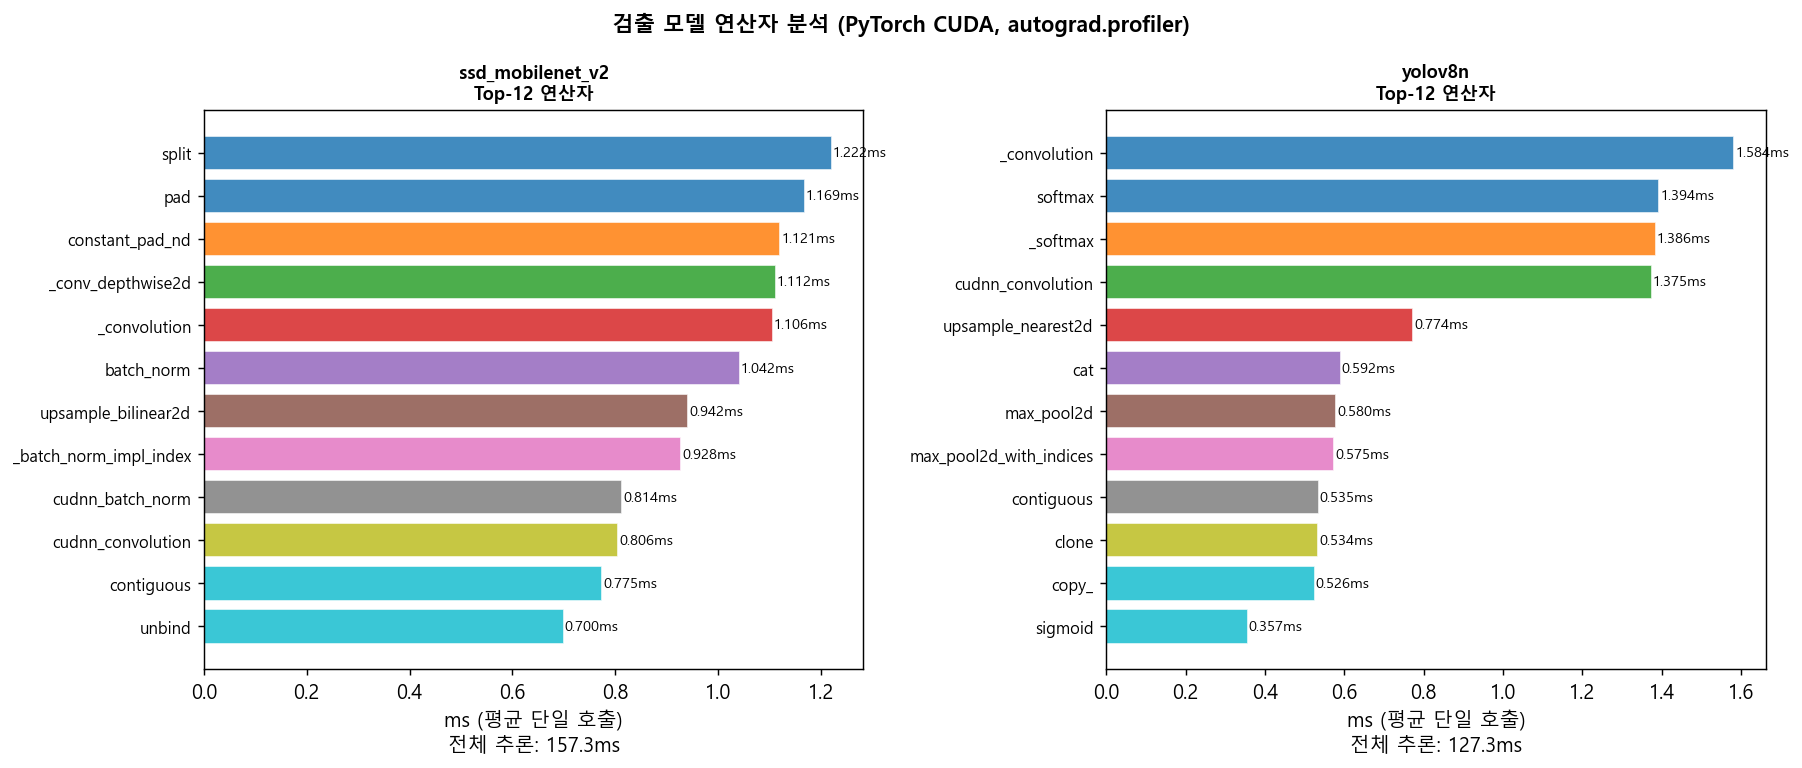

저장: results/det_layer_analysis.png

=== 분류 모델 레이어 타입 시간 비율 (%) ===
                    Conv2d  BatchNorm2d  ReLU  Hardswish  Linear  AdaptiveAvgPool2d
mobilenetv3_small     53.4         21.0   6.3        7.7     2.1                5.2
shufflenet_v2_x1_0    52.3         31.4  13.9        0.0     1.3                0.0
efficientnet_b0       60.3         17.4   0.0        0.0     0.6                4.9
resnet50              78.3         15.9   4.0        0.0     0.6                0.3


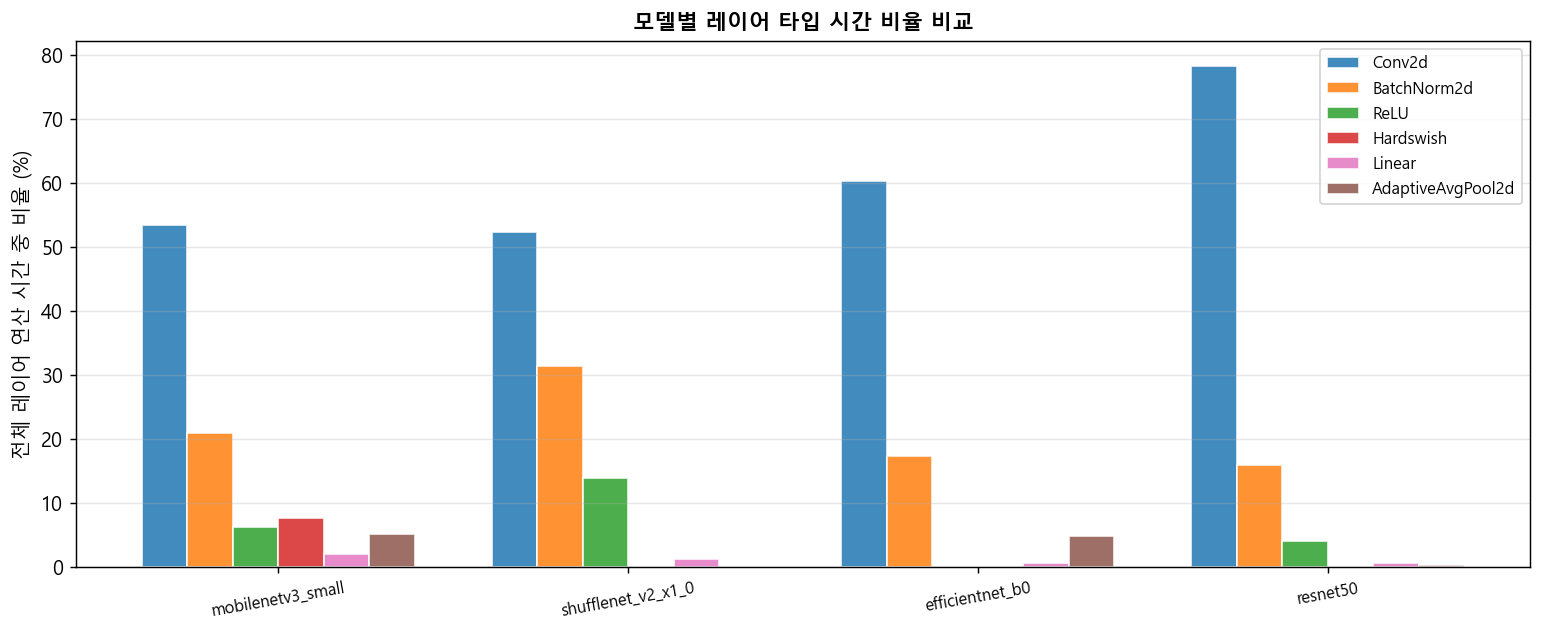

저장: results/layer_type_comparison.png


In [26]:
import os

# 레이어 CSV 로드
layer_dir = '../results'
layer_models_info = {
    'mobilenetv3_small':  'classification',
    'shufflenet_v2_x1_0': 'classification',
    'efficientnet_b0':    'classification',
    'resnet50':           'classification',
    'ssd_mobilenet_v2':   'detection',
    'yolov8n':            'detection',
}

layers = {}
print('=== 레이어 프로파일링 데이터 로드 ===')
for model, mtype in layer_models_info.items():
    path = os.path.join(layer_dir, f'{model}_layers.csv')
    if os.path.exists(path):
        df_l = pd.read_csv(path)
        layers[model] = (df_l, mtype)
        total_ms = df_l['mean_ms'].sum()
        print(f'{model:30s} ({mtype:14s}): {len(df_l):3d} ops,  합산 {total_ms:.1f} ms')

# ── (A) 분류 모델: Top-15 병목 레이어 + 타입 분포 ──────────────────────────────
clf_layer_models = ['mobilenetv3_small', 'shufflenet_v2_x1_0', 'efficientnet_b0', 'resnet50']
type_colors = {
    'Conv2d': '#1f77b4', 'BatchNorm2d': '#ff7f0e', 'ReLU': '#2ca02c',
    'Hardswish': '#d62728', 'Hardsigmoid': '#9467bd',
    'AdaptiveAvgPool2d': '#8c564b', 'Linear': '#e377c2',
    'Dropout': '#7f7f7f', 'MaxPool2d': '#bcbd22',
}

fig, axes = plt.subplots(2, 4, figsize=(22, 12))

for col, model in enumerate(clf_layer_models):
    df_l, _ = layers[model]

    # --- Top-15 병목 레이어 (가로 막대) ---
    top15 = df_l.nlargest(15, 'mean_ms').copy()
    short_names = []
    for n in top15['layer_name']:
        parts = n.split('.')
        short_names.append('.'.join(parts[-3:]) if len(parts) >= 3 else n)

    ax1 = axes[0][col]
    bar_colors = [type_colors.get(t, '#333333') for t in top15['layer_type']]
    ax1.barh(range(len(top15)), top15['mean_ms'], color=bar_colors, edgecolor='white', alpha=0.85)
    ax1.set_yticks(range(len(top15)))
    ax1.set_yticklabels(short_names, fontsize=6.5)
    ax1.invert_yaxis()
    ax1.set_xlabel('ms')
    ax1.set_title(f'{model}\nTop-15 병목 레이어', fontsize=9, fontweight='bold')
    for i, (val, lt) in enumerate(zip(top15['mean_ms'], top15['layer_type'])):
        ax1.text(val + 0.01, i, f'{val:.2f}ms ({lt})', va='center', fontsize=5.5)

    # --- 레이어 타입별 총 연산 시간 파이 차트 ---
    ax2 = axes[1][col]
    type_time = df_l.groupby('layer_type')['mean_ms'].sum().sort_values(ascending=False)
    pie_colors = [type_colors.get(t, '#aaaaaa') for t in type_time.index]
    ax2.pie(type_time.values, labels=None, autopct='%1.0f%%',
            colors=pie_colors, startangle=90, pctdistance=0.75,
            textprops={'fontsize': 7})
    ax2.legend(type_time.index, loc='lower center', fontsize=6, ncol=2,
               bbox_to_anchor=(0.5, -0.38))
    ax2.set_title(f'레이어 타입 비율\n합산 {type_time.sum():.1f}ms', fontsize=8)

# 범례 (레이어 타입 색상)
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in type_colors.items()]
fig.legend(handles=legend_patches, loc='upper center', ncol=len(type_colors),
           fontsize=8, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('분류 모델 레이어별 분석 (PyTorch CPU 프로파일링)', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../results/clf_layer_analysis.png', bbox_inches='tight')
plt.show()
print('저장: results/clf_layer_analysis.png')

# ── (B) 검출 모델: aten 연산자 분석 ─────────────────────────────────────────────
det_models = ['ssd_mobilenet_v2', 'yolov8n']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col, model in enumerate(det_models):
    df_l, _ = layers[model]
    total_row = df_l[df_l['layer_name'] == 'forward']
    total_ms = total_row['mean_ms'].values[0] if len(total_row) > 0 else 0

    ops = df_l[df_l['layer_name'] != 'forward'].nlargest(12, 'mean_ms').copy()
    short_ops = [n.replace('aten::', '') for n in ops['layer_name']]

    ax = axes[col]
    op_colors = plt.cm.tab10(np.linspace(0, 1, len(ops)))
    ax.barh(range(len(ops)), ops['mean_ms'], color=op_colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(ops)))
    ax.set_yticklabels(short_ops, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(f'ms (평균 단일 호출)\n전체 추론: {total_ms:.1f}ms')
    ax.set_title(f'{model}\nTop-12 연산자', fontsize=10, fontweight='bold')
    for i, val in enumerate(ops['mean_ms']):
        ax.text(val + 0.002, i, f'{val:.3f}ms', va='center', fontsize=8)

fig.suptitle('검출 모델 연산자 분석 (PyTorch CUDA, autograd.profiler)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/det_layer_analysis.png', bbox_inches='tight')
plt.show()
print('저장: results/det_layer_analysis.png')

# ── (C) 분류 모델 간 레이어 타입 시간 비율 비교 ────────────────────────────────
key_types = ['Conv2d', 'BatchNorm2d', 'ReLU', 'Hardswish', 'Linear', 'AdaptiveAvgPool2d']
compare_data = {}
for model in clf_layer_models:
    df_l, _ = layers[model]
    type_time = df_l.groupby('layer_type')['mean_ms'].sum()
    total = type_time.sum()
    compare_data[model] = {t: round(type_time.get(t, 0) / total * 100, 1) for t in key_types}

compare_df = pd.DataFrame(compare_data).T.fillna(0)
print('\n=== 분류 모델 레이어 타입 시간 비율 (%) ===')
print(compare_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(clf_layer_models))
width = 0.13
for i, lt in enumerate(key_types):
    vals = compare_df[lt].values if lt in compare_df.columns else [0]*len(clf_layer_models)
    ax.bar(x + i * width, vals, width, label=lt,
           color=type_colors.get(lt, '#aaaaaa'), edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * (len(key_types) - 1) / 2)
ax.set_xticklabels(clf_layer_models, rotation=10, fontsize=9)
ax.set_ylabel('전체 레이어 연산 시간 중 비율 (%)')
ax.set_title('모델별 레이어 타입 시간 비율 비교', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../results/layer_type_comparison.png', bbox_inches='tight')
plt.show()
print('저장: results/layer_type_comparison.png')

### 레이어 분석 해석

**분류 모델: Conv2d가 전체 연산 시간의 70~85%를 차지**
- 2D Convolution의 연산량 = `out_ch × in_ch × kH × kW × H_out × W_out` — 채널 수와 해상도가 곱으로 증가
- ResNet-50 `layer4.conv2` 하나가 5.6ms → MobileNetV3 최고 병목 레이어(1.4ms)의 **4배**
- 이것이 파라미터 수(25.6M vs 2.5M)만으로 속도 차이를 설명하기 어려운 이유: **채널 수 × 공간 해상도의 곱**이 실제 연산량

**MobileNetV3-Small SE Block 비용**
- `features.0.0` (224²→112²)이 첫 레이어임에도 1.43ms로 가장 느림 → 입력 해상도가 가장 크기 때문
- SE Block의 fc1/fc2 (Linear, ~0.7ms): 파라미터 수는 적지만 메모리 접근 패턴이 불규칙 → 캐시 효율 낮음

**검출 모델: Convolution 외 텐서 변환 연산도 큰 비중**
- SSD: `aten::_conv_depthwise2d` — MobileNetV2 Depthwise Conv가 단독 병목
- YOLOv8n: `aten::upsample_nearest2d`(FPN neck 업샘플링) + `aten::cat`(feature map 연결) 비중 높음
  - 640² 입력 → FPN에서 80×80, 40×40, 20×20 세 스케일을 처리하는 비용
  - `aten::softmax`: Anchor-free head의 클래스 점수 정규화

**TRT Layer Fusion이 의미하는 것**
- Conv2d + BatchNorm2d + ReLU → 단일 GPU 커널로 합쳐짐
- 결과: BN 레이어의 메모리 왕복 비용 제거, 중간 feature map 저장 불필요
- 이 레이어 분석 데이터(PyTorch CPU 기준)에서 BN이 10~15%를 차지하는데, TRT에서는 사실상 0% → **TRT 20~50x 가속의 핵심 이유**

---
## 3. 런타임별 분석

### 핵심 질문: 같은 모델인데 왜 런타임마다 속도가 다른가?

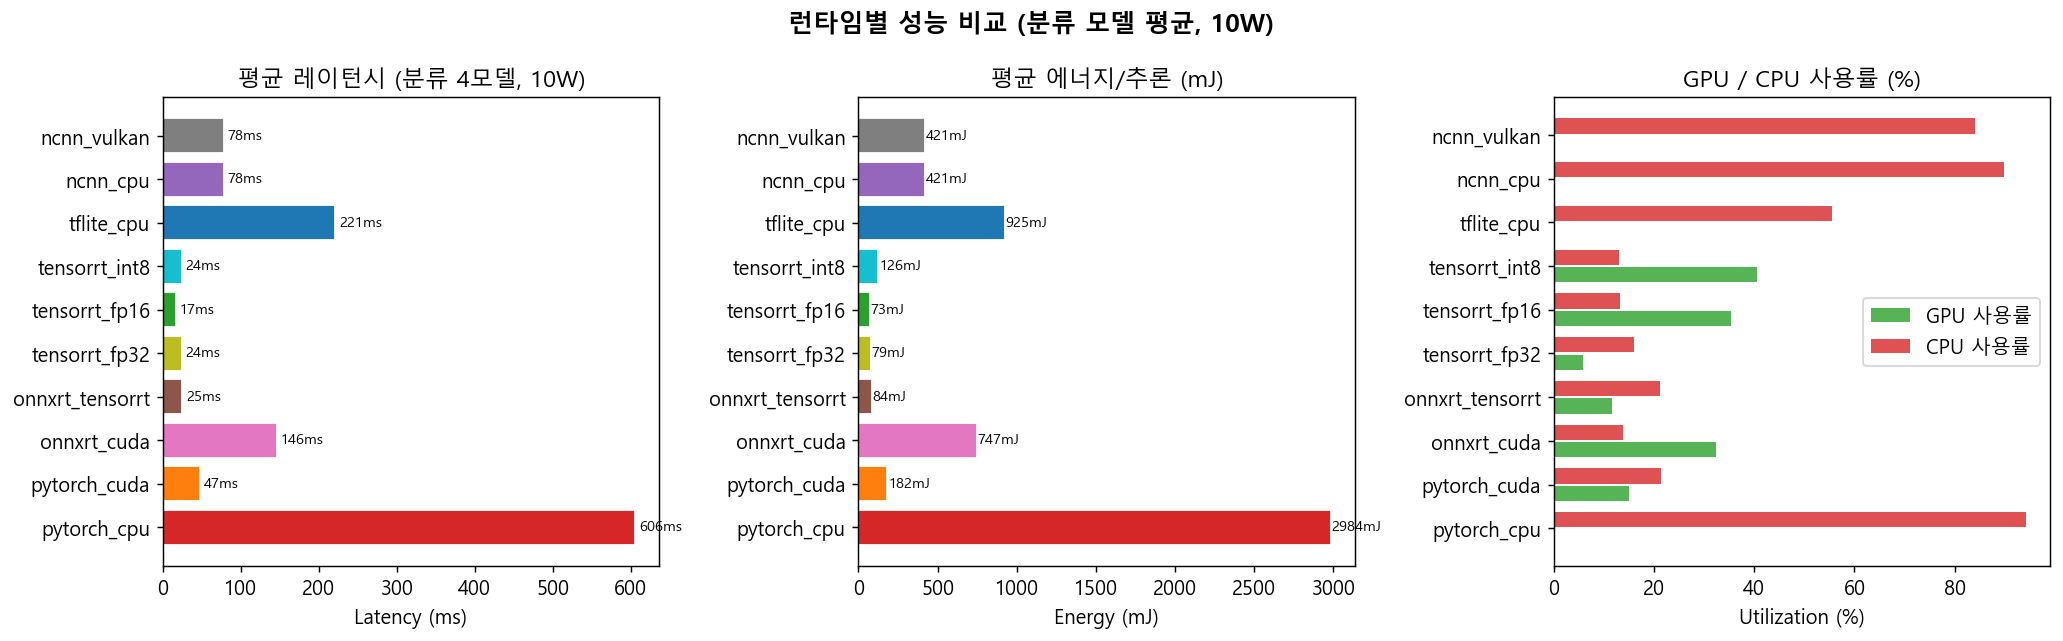

In [27]:
# 런타임별 평균 레이턴시 (모든 모델 평균, 10W)
runtime_order = ['pytorch_cpu', 'pytorch_cuda', 'onnxrt_cuda', 'onnxrt_tensorrt',
                 'tensorrt_fp32', 'tensorrt_fp16', 'tensorrt_int8',
                 'tflite_cpu', 'ncnn_cpu', 'ncnn_vulkan']

# 분류 모델만 (공정 비교)
clf_models = ['mobilenetv3_small', 'shufflenet_v2_x1_0', 'efficientnet_b0', 'resnet50']
df_clf = df_10w[df_10w['model'].isin(clf_models)]

rt_stats = df_clf.groupby('runtime').agg(
    latency_mean = ('latency_mean_ms', 'mean'),
    energy_mean  = ('energy_per_inference_mj', lambda x: x[x>0].mean()),
    gpu_util     = ('gpu_util_mean_pct', 'mean'),
    cpu_util     = ('cpu_util_mean_pct', 'mean'),
).round(2)

rt_stats = rt_stats.reindex([r for r in runtime_order if r in rt_stats.index])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

rt_colors = {
    'pytorch_cpu': '#d62728', 'pytorch_cuda': '#ff7f0e',
    'onnxrt_cuda': '#e377c2', 'onnxrt_tensorrt': '#8c564b',
    'tensorrt_fp32': '#bcbd22', 'tensorrt_fp16': '#2ca02c', 'tensorrt_int8': '#17becf',
    'tflite_cpu': '#1f77b4', 'ncnn_cpu': '#9467bd', 'ncnn_vulkan': '#7f7f7f'
}
bar_colors = [rt_colors.get(r, '#333') for r in rt_stats.index]

# 레이턴시
axes[0].barh(rt_stats.index, rt_stats['latency_mean'], color=bar_colors, edgecolor='white')
axes[0].set_title('평균 레이턴시 (분류 4모델, 10W)')
axes[0].set_xlabel('Latency (ms)')
for i, v in enumerate(rt_stats['latency_mean']):
    axes[0].text(v + 5, i, f'{v:.0f}ms', va='center', fontsize=8)

# 에너지
axes[1].barh(rt_stats.index, rt_stats['energy_mean'], color=bar_colors, edgecolor='white')
axes[1].set_title('평균 에너지/추론 (mJ)')
axes[1].set_xlabel('Energy (mJ)')
for i, v in enumerate(rt_stats['energy_mean']):
    if not np.isnan(v):
        axes[1].text(v + 5, i, f'{v:.0f}mJ', va='center', fontsize=8)

# GPU/CPU 사용률
x = np.arange(len(rt_stats))
axes[2].barh(x - 0.2, rt_stats['gpu_util'], 0.35, label='GPU 사용률', color='#2ca02c', alpha=0.8)
axes[2].barh(x + 0.2, rt_stats['cpu_util'], 0.35, label='CPU 사용률', color='#d62728', alpha=0.8)
axes[2].set_yticks(x)
axes[2].set_yticklabels(rt_stats.index)
axes[2].set_title('GPU / CPU 사용률 (%)')
axes[2].set_xlabel('Utilization (%)')
axes[2].legend()

plt.suptitle('런타임별 성능 비교 (분류 모델 평균, 10W)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/runtime_comparison.png', bbox_inches='tight')
plt.show()

### 런타임 분석 해석

**PyTorch CPU가 가장 느린 이유**
- Eager Execution: 연산을 하나씩 순차 실행 → 그래프 최적화 없음
- Python overhead: 각 op마다 Python 인터프리터 호출
- ARM CPU에서 SIMD 최적화 미적용
- Jetson Nano ARM Cortex-A57은 x86 대비 SIMD 폭이 좁음

**TensorRT FP16이 가장 빠른 이유**
- Layer Fusion: Conv + BN + ReLU를 하나의 커널로 합침 → 메모리 왕복 최소화
- Kernel Auto-tuning: Jetson Nano Maxwell GPU에 최적화된 커널 선택
- FP16 연산: Maxwell GPU는 FP16 연산 유닛이 FP32보다 2배 빠름
- Workspace 캐시: 엔진 빌드 시 최적 알고리즘을 미리 선택해 저장

**ncnn_vulkan이 ncnn_cpu보다 느린 경우가 있는 이유**
- Maxwell GPU는 Vulkan Compute Shader 지원이 제한적
- 소형 텐서(224×224)는 GPU 전송 overhead가 연산 시간을 초과
- 검출 모델(640×640)에서는 반대로 Vulkan이 빠름 → 입력 크기 임계점 존재

**ONNX Runtime이 PyTorch CUDA보다 빠른 이유**
- ONNX 그래프 최적화: Constant Folding, Operator Fusion 적용
- CUDAExecutionProvider: cuDNN 커널 직접 호출
- Python overhead 없음: C++ 런타임으로 직접 실행

**TFLite CPU가 PyTorch CPU보다 빠른 이유**
- FlatBuffer 형식: 역직렬화 없이 메모리 직접 매핑
- XNNPACK delegate: ARM NEON SIMD 명령어 최적화
- 정적 그래프: 실행 전 메모리 레이아웃을 미리 계획

---
## 4. 양자화 효과 분석 

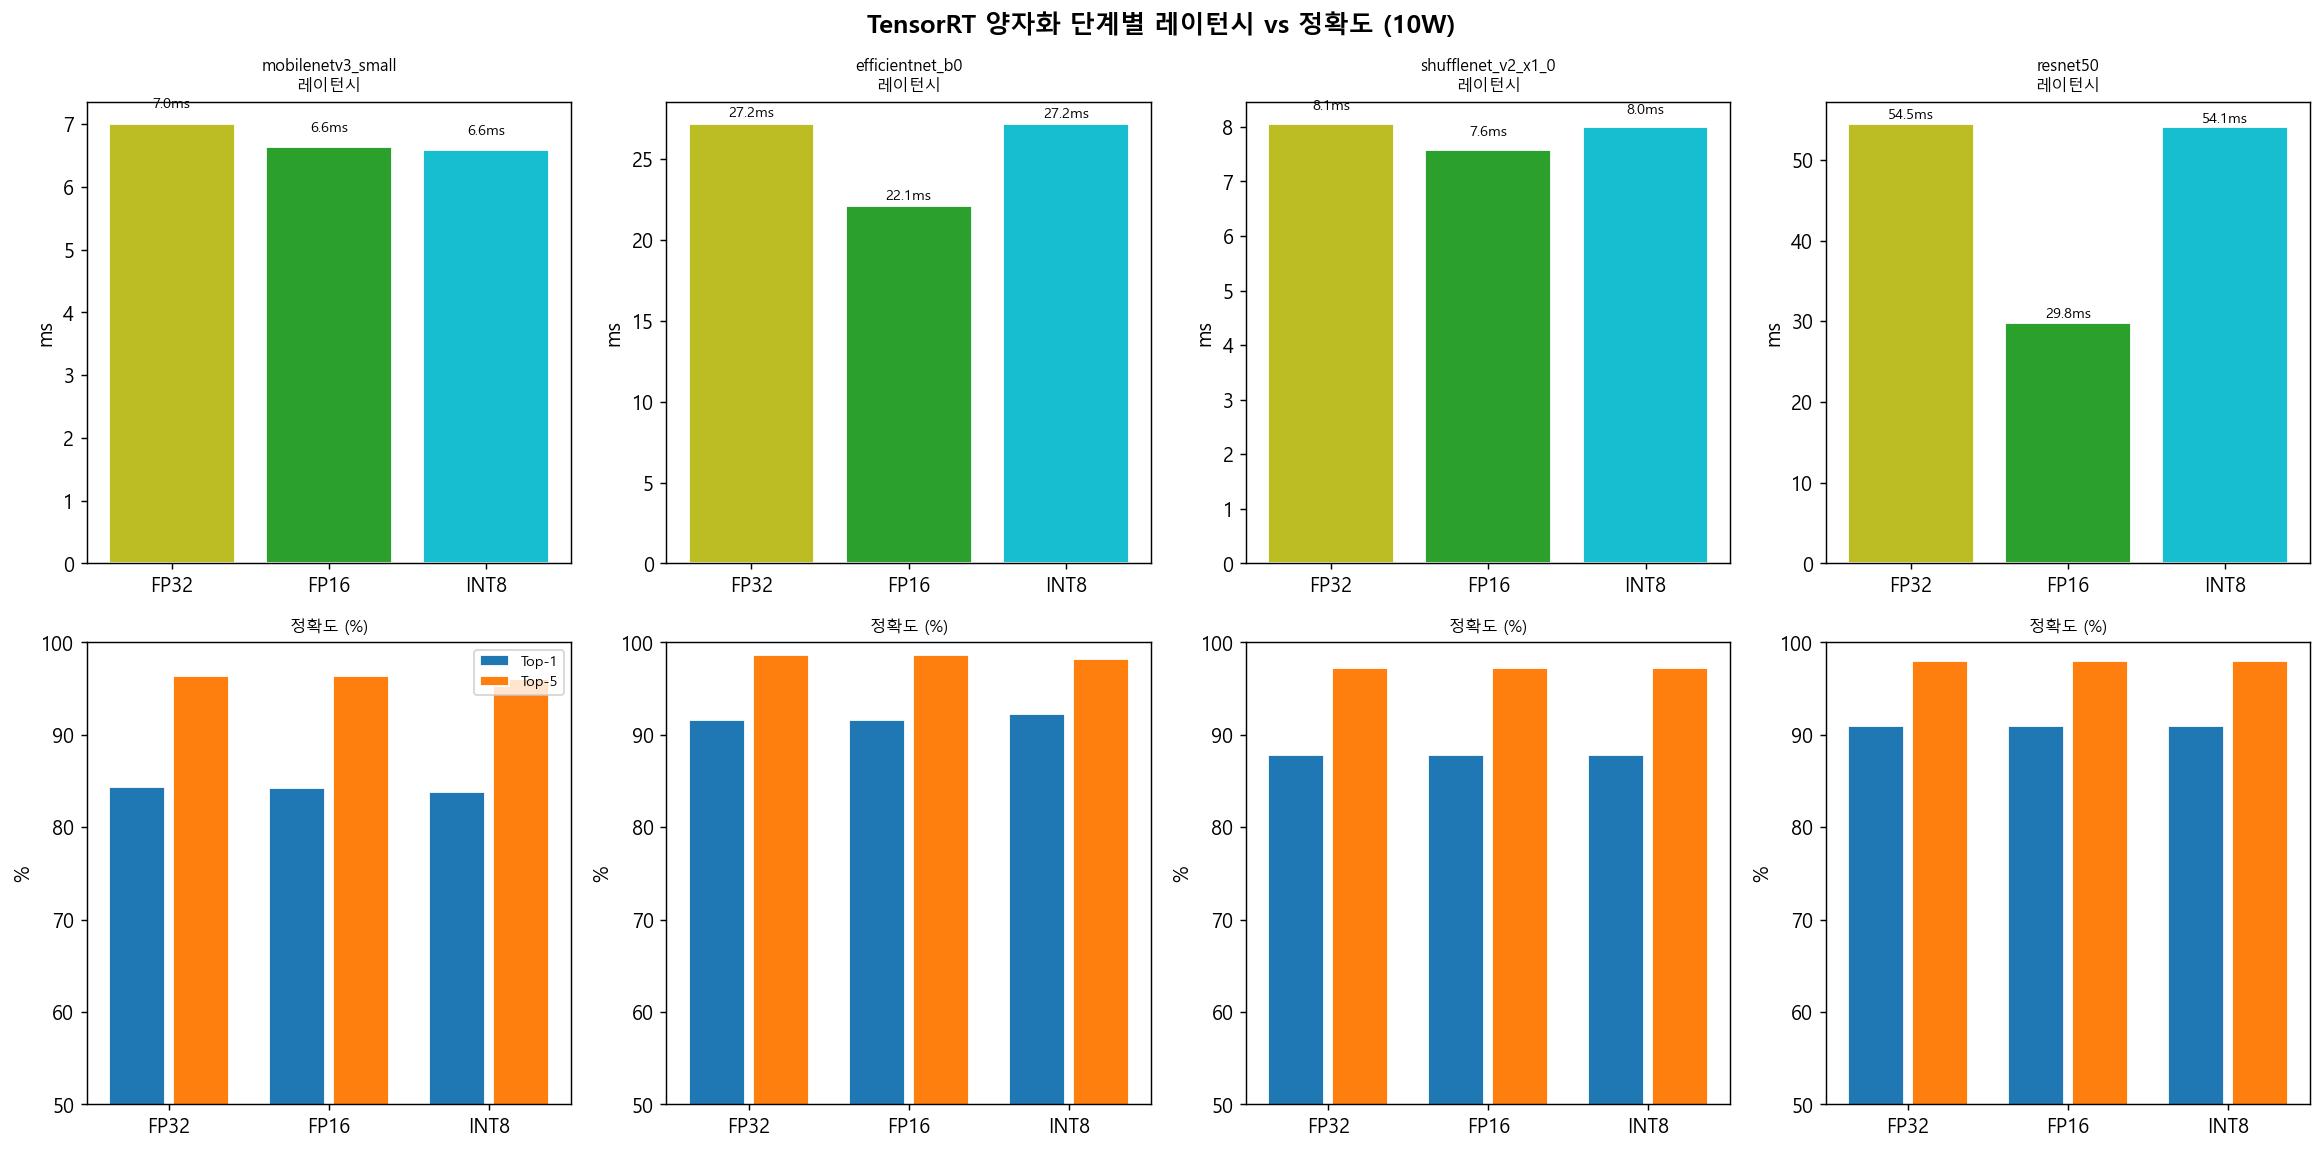

In [20]:
# TRT FP32 vs FP16 vs INT8 : 레이턴시 + 정확도
acc_files = {
    'mobilenetv3_small': '../results/mobilenetv3_small_accuracy_complete.csv',
    'efficientnet_b0':   '../results/efficientnet_b0_accuracy_complete.csv',
    'shufflenet_v2_x1_0': '../results/shufflenet_v2_x1_0_accuracy_complete.csv',
    'resnet50':          '../results/resnet50_accuracy_complete.csv',
}

trt_runtimes = ['tensorrt_fp32', 'tensorrt_fp16', 'tensorrt_int8']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, model in enumerate(acc_files.keys()):
    acc_df = pd.read_csv(acc_files[model])
    acc_df = acc_df[acc_df['runtime'].isin(['tensorrt_fp32', 'tensorrt_fp16', 'tensorrt_int8'])]
    lat_df = df_10w[(df_10w['model'] == model) & (df_10w['runtime'].isin(trt_runtimes))]

    # 레이턴시
    ax1 = axes[0][col]
    lat_data = lat_df.set_index('runtime').reindex(trt_runtimes)
    bars = ax1.bar(['FP32', 'FP16', 'INT8'], lat_data['latency_mean_ms'],
                   color=['#bcbd22', '#2ca02c', '#17becf'], edgecolor='white')
    for bar, val in zip(bars, lat_data['latency_mean_ms']):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}ms', ha='center', va='bottom', fontsize=8)
    ax1.set_title(f'{model}\n레이턴시', fontsize=9)
    ax1.set_ylabel('ms')

    # 정확도
    ax2 = axes[1][col]
    acc_data = acc_df.set_index('runtime').reindex(trt_runtimes)
    x = np.arange(3)
    ax2.bar(x - 0.2, acc_data['top1'], 0.35, label='Top-1', color='#1f77b4', edgecolor='white')
    ax2.bar(x + 0.2, acc_data['top5'], 0.35, label='Top-5', color='#ff7f0e', edgecolor='white')
    ax2.set_xticks(x)
    ax2.set_xticklabels(['FP32', 'FP16', 'INT8'])
    ax2.set_title(f'정확도 (%)', fontsize=9)
    ax2.set_ylim(50, 100)
    ax2.set_ylabel('%')
    if col == 0:
        ax2.legend(fontsize=8)

fig.suptitle('TensorRT 양자화 단계별 레이턴시 vs 정확도 (10W)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/quantization_analysis.png', bbox_inches='tight')
plt.show()

### 양자화 분석 해석

**FP32 → FP16: 안전한 선택**
- 지수부/가수부 비트 수만 줄이고 범위는 유지
- Maxwell GPU FP16 연산 유닛 활용 → 속도 1.3~1.5x 향상
- 분류 모델 Top-1 손실: 평균 0.2~0.4pp → 실용적으로 무시 가능
- 검출 모델(YOLOv8n) mAP 손실: 0.0002 → 사실상 동일

**FP32 → INT8: 분류 모델은 괜찮지만 검출 모델은 위험**
- 8비트 정수로 가중치/활성화를 표현 → 캘리브레이션 필수
- 분류 모델: Top-1 손실 0.6~1.0pp 수준으로 허용 가능
- **YOLOv8n INT8: mAP 0.408 → 0.019 (95% 붕괴!)**
  - 예측 수: 2134개 → 152개 (93% 감소)
  - 원인: YOLOv8n의 Anchor-free head 출력 텐서 [1,84,8400]은
    활성화 분포가 불균일 → INT8 캘리브레이션 범위 설정 실패
  - CSP Bottleneck의 분기 구조가 INT8 스케일 불일치를 증폭
  - **결론: 검출 모델 INT8 양자화는 QAT(Quantization-Aware Training) 없이 PTQ만으로는 위험**

---
## 5. 5W 패러독스 — 전력 절감 ≠ 에너지 절감

에너지 패러독스 케이스 (5W가 더 비효율): 47개 / 전체 60개

             model       runtime  power_10w  power_5w  lat_10w  lat_5w  energy_10w  energy_5w  energy_ratio
shufflenet_v2_x1_0    tflite_cpu    4218.14   2196.71    19.76 3121.60       83.33    6857.25         82.29
  ssd_mobilenet_v2    tflite_cpu    4825.00   2266.47   143.42 3563.60      692.01    8076.80         11.67
           yolov8n    tflite_cpu    6061.85   2427.64   351.44 3127.20     2130.40    7591.72          3.56
shufflenet_v2_x1_0   onnxrt_cuda    2852.50   2630.08    15.85   51.27       45.20     134.83          2.98
 mobilenetv3_small   onnxrt_cuda    3016.10   2588.76    11.11   20.49       33.51      53.04          1.58
 mobilenetv3_small tensorrt_fp32    2766.70   2286.73     7.01   12.87       19.40      29.42          1.52
 mobilenetv3_small      ncnn_cpu    3995.50   2879.20     9.47   19.11       37.83      55.02          1.45
          resnet50    tflite_cpu    4660.35   2643.55   524.13 1336.60     2442.62    3533.37   

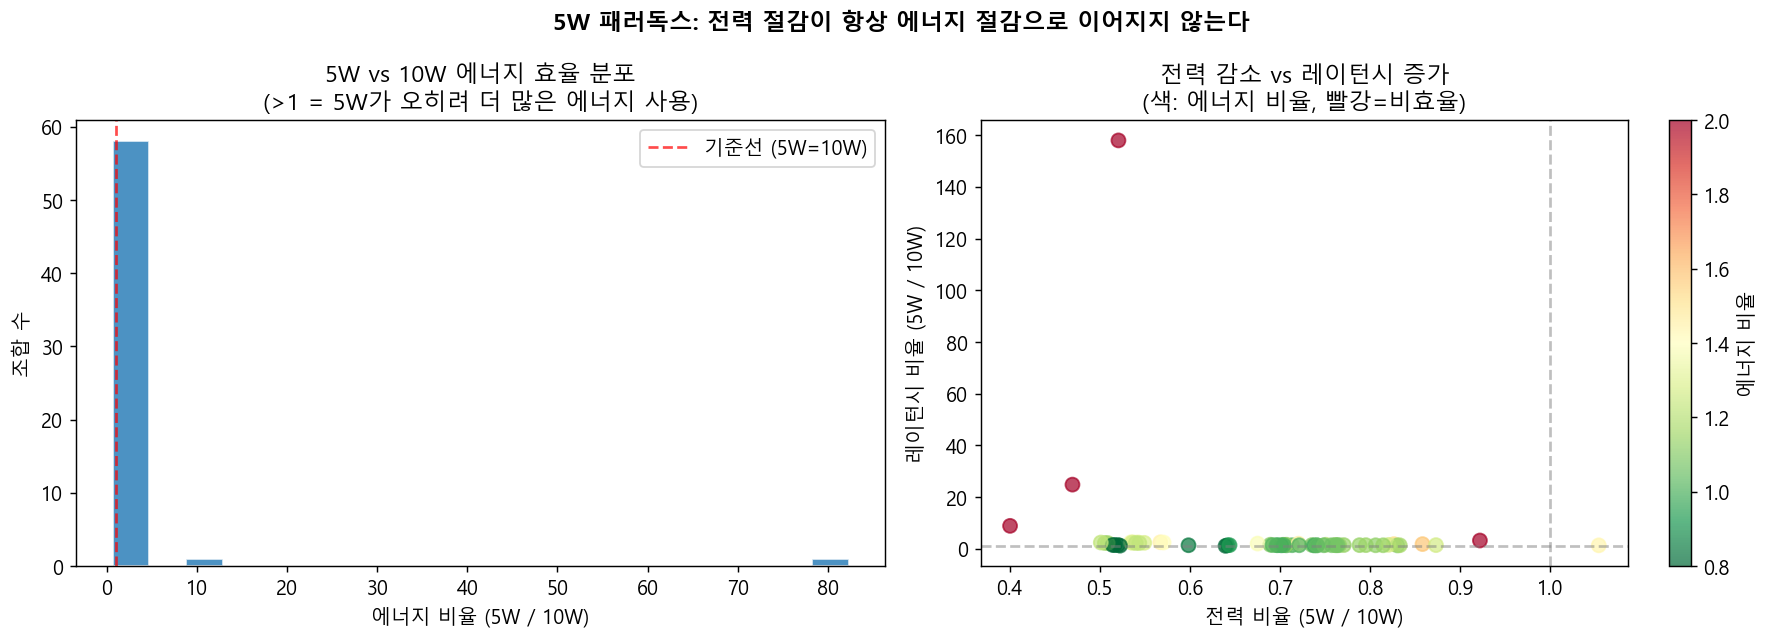

In [22]:
# 10W vs 5W 에너지/추론 비교
merged = df_10w[['model','runtime','latency_mean_ms','energy_per_inference_mj','power_in_mean_mw']].copy()
merged = merged.rename(columns={
    'latency_mean_ms': 'lat_10w',
    'energy_per_inference_mj': 'energy_10w',
    'power_in_mean_mw': 'power_10w'
})
merged5 = df_5w[['model','runtime','latency_mean_ms','energy_per_inference_mj','power_in_mean_mw']].rename(columns={
    'latency_mean_ms': 'lat_5w',
    'energy_per_inference_mj': 'energy_5w',
    'power_in_mean_mw': 'power_5w'
})
cmp = merged.merge(merged5, on=['model','runtime'])
cmp = cmp[(cmp['energy_10w']>0) & (cmp['energy_5w']>0)]
cmp['energy_ratio'] = cmp['energy_5w'] / cmp['energy_10w']  # >1 이면 5W가 더 비효율
cmp['lat_ratio']    = cmp['lat_5w'] / cmp['lat_10w']
cmp['power_ratio']  = cmp['power_5w'] / cmp['power_10w']

# 패러독스 케이스 필터
paradox = cmp[cmp['energy_ratio'] > 1.0].sort_values('energy_ratio', ascending=False)
print(f'에너지 패러독스 케이스 (5W가 더 비효율): {len(paradox)}개 / 전체 {len(cmp)}개')
print()
print(paradox[['model','runtime','power_10w','power_5w','lat_10w','lat_5w','energy_10w','energy_5w','energy_ratio']]
      .head(10).round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 에너지 비율 분포
axes[0].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='기준선 (5W=10W)')
axes[0].hist(cmp['energy_ratio'], bins=20, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('에너지 비율 (5W / 10W)')
axes[0].set_ylabel('조합 수')
axes[0].set_title('5W vs 10W 에너지 효율 분포\n(>1 = 5W가 오히려 더 많은 에너지 사용)')
axes[0].legend()

# 전력 절감 vs 레이턴시 증가 산점도
sc = axes[1].scatter(cmp['power_ratio'], cmp['lat_ratio'],
                     c=cmp['energy_ratio'], cmap='RdYlGn_r', s=60, alpha=0.7, vmin=0.8, vmax=2.0)
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=1.0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('전력 비율 (5W / 10W)')
axes[1].set_ylabel('레이턴시 비율 (5W / 10W)')
axes[1].set_title('전력 감소 vs 레이턴시 증가\n(색: 에너지 비율, 빨강=비효율)')
plt.colorbar(sc, ax=axes[1], label='에너지 비율')

plt.suptitle('5W 패러독스: 전력 절감이 항상 에너지 절감으로 이어지지 않는다', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/5w_paradox_analysis.png', bbox_inches='tight')
plt.show()

### 5W 패러독스 해석

**에너지(mJ) = 전력(mW) × 시간(ms)**

5W 모드에서:
- CPU 클럭: 1.43GHz → 0.92GHz (35% 감소)
- GPU 클럭: 921MHz → 640MHz (30% 감소)
- 전력 소비: ~40% 감소
- 레이턴시: 평균 60~80% 증가

따라서 `전력 0.6 × 시간 1.7 = 에너지 1.02` → **에너지가 오히려 증가**

특히 CPU 의존적인 런타임(pytorch_cpu, tflite_cpu, ncnn_cpu)에서 패러독스가 두드러진다.
GPU 가속 런타임(TRT, CUDA)은 상대적으로 패러독스가 약하다 — GPU 클럭 감소폭이 CPU보다 작기 때문이다.

---
## 6. 정확도 vs 효율 Trade-off

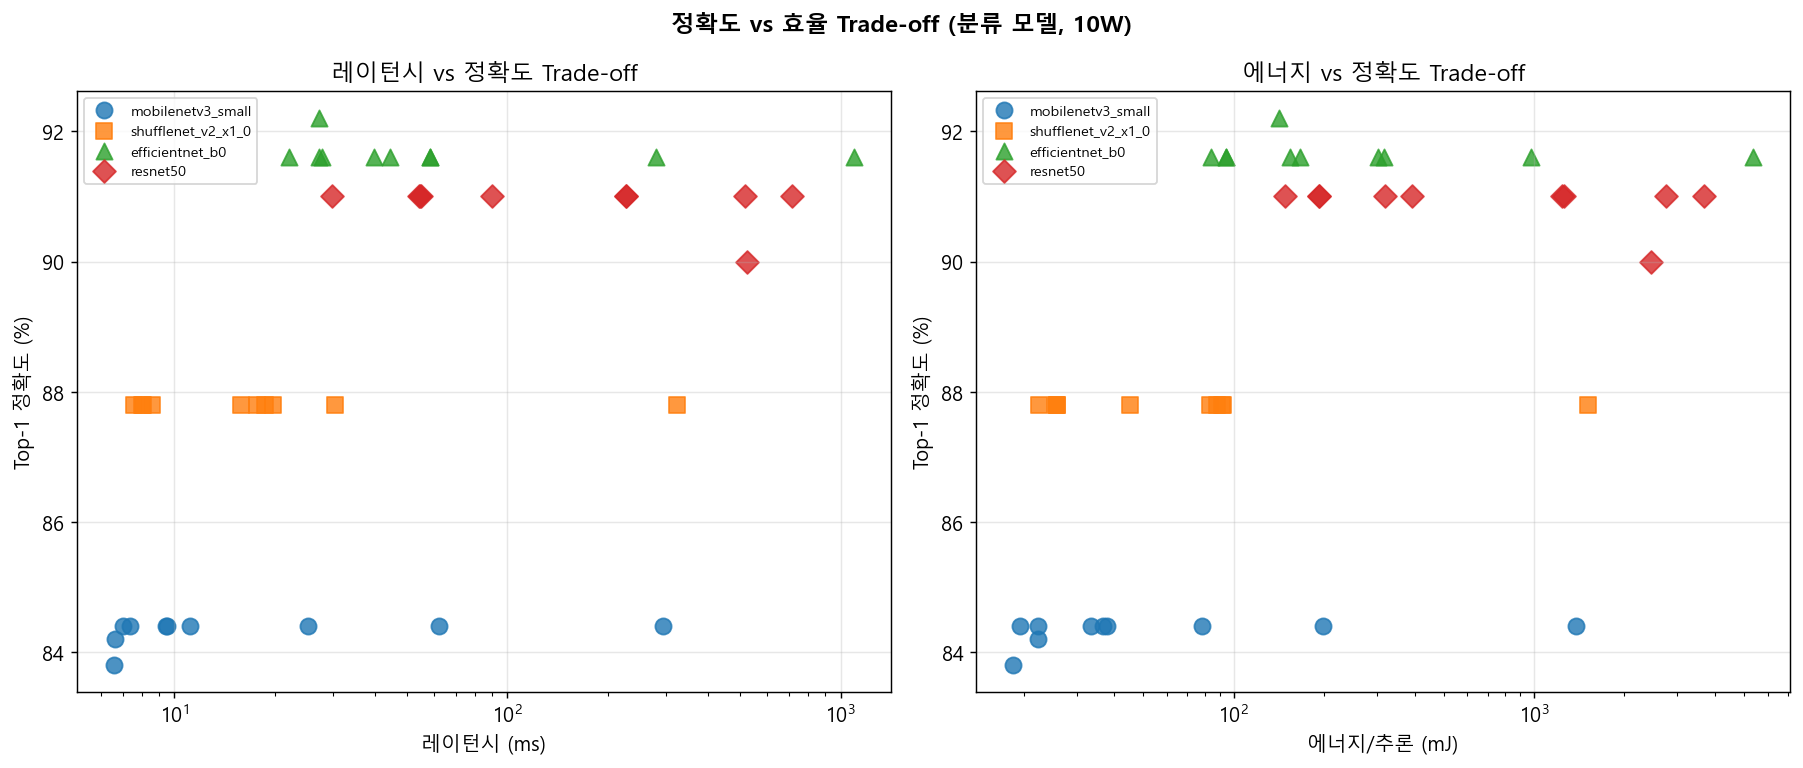

In [23]:
# 분류 모델: 런타임별 정확도 vs 에너지 효율
acc_all = []
for model, path in acc_files.items():
    a = pd.read_csv(path)
    a['model'] = model
    acc_all.append(a)
acc_df = pd.concat(acc_all)
acc_df['runtime'] = acc_df['runtime'].replace({'onnxrt_trt': 'onnxrt_tensorrt'})

tradeoff = acc_df.merge(
    df_10w[['model','runtime','latency_mean_ms','energy_per_inference_mj']],
    on=['model','runtime'], how='inner'
)
tradeoff = tradeoff[tradeoff['status']=='measured']
tradeoff = tradeoff[tradeoff['energy_per_inference_mj']>0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_markers = {'mobilenetv3_small': 'o', 'shufflenet_v2_x1_0': 's',
                 'efficientnet_b0': '^', 'resnet50': 'D'}
model_colors  = {'mobilenetv3_small': '#1f77b4', 'shufflenet_v2_x1_0': '#ff7f0e',
                 'efficientnet_b0': '#2ca02c', 'resnet50': '#d62728'}

for model in clf_models:
    d = tradeoff[tradeoff['model']==model]
    axes[0].scatter(d['latency_mean_ms'], d['top1'],
                    marker=model_markers[model], color=model_colors[model],
                    s=80, alpha=0.8, label=model)
    axes[1].scatter(d['energy_per_inference_mj'], d['top1'],
                    marker=model_markers[model], color=model_colors[model],
                    s=80, alpha=0.8, label=model)

axes[0].set_xlabel('레이턴시 (ms)')
axes[0].set_ylabel('Top-1 정확도 (%)')
axes[0].set_title('레이턴시 vs 정확도 Trade-off')
axes[0].set_xscale('log')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('에너지/추론 (mJ)')
axes[1].set_ylabel('Top-1 정확도 (%)')
axes[1].set_title('에너지 vs 정확도 Trade-off')
axes[1].set_xscale('log')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('정확도 vs 효율 Trade-off (분류 모델, 10W)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/accuracy_efficiency_tradeoff.png', bbox_inches='tight')
plt.show()

---
## 7. 종합 인사이트 — 실제 서비스라면 무엇을 선택할까

In [24]:
# 시나리오별 최적 조합 도출
print('='*65)
print('시나리오별 최적 조합 (10W 기준)')
print('='*65)

valid = df_10w[df_10w['latency_mean_ms'] > 0].copy()

scenarios = [
    ('최저 레이턴시',       valid.loc[valid['latency_mean_ms'].idxmin()]),
    ('최저 에너지/추론',    valid[valid['energy_per_inference_mj']>0].loc[
                             valid[valid['energy_per_inference_mj']>0]['energy_per_inference_mj'].idxmin()]),
    ('최저 탄소/추론',      valid[valid['co2_per_inference_mg']>0].loc[
                             valid[valid['co2_per_inference_mg']>0]['co2_per_inference_mg'].idxmin()]),
    ('최저 메모리 사용',    valid.loc[valid['ram_delta_mb'].idxmin()]),
]

for name, row in scenarios:
    print(f'\n[{name}]')
    print(f'  모델: {row["model"]}  /  런타임: {row["runtime"]}')
    print(f'  레이턴시: {row["latency_mean_ms"]:.2f}ms  |  에너지: {row["energy_per_inference_mj"]:.1f}mJ  |  CO₂: {row["co2_per_inference_mg"]:.3f}mg')

print('\n' + '='*65)
print('최고 탄소 효율 Top-5 (에너지 기준)')
print('='*65)
top5 = valid[valid['energy_per_inference_mj']>0].nsmallest(5, 'energy_per_inference_mj')
print(top5[['model','runtime','latency_mean_ms','energy_per_inference_mj','co2_per_inference_mg']].round(3).to_string(index=False))

print('\n' + '='*65)
print('PyTorch CPU 대비 TRT FP16 탄소 절감률 (모델별)')
print('='*65)
for model in models_order:
    pt = valid[(valid['model']==model) & (valid['runtime']=='pytorch_cpu')]['co2_per_inference_mg'].values
    trt = valid[(valid['model']==model) & (valid['runtime']=='tensorrt_fp16')]['co2_per_inference_mg'].values
    if len(pt)>0 and len(trt)>0 and trt[0]>0:
        ratio = pt[0] / trt[0]
        print(f'  {model:30s}: {ratio:5.1f}배 절감 ({pt[0]:.1f} → {trt[0]:.1f} mgCO₂)')

시나리오별 최적 조합 (10W 기준)

[최저 레이턴시]
  모델: mobilenetv3_small  /  런타임: tensorrt_int8
  레이턴시: 6.58ms  |  에너지: 18.4mJ  |  CO₂: 2.352mg

[최저 에너지/추론]
  모델: mobilenetv3_small  /  런타임: tensorrt_int8
  레이턴시: 6.58ms  |  에너지: 18.4mJ  |  CO₂: 2.352mg

[최저 탄소/추론]
  모델: mobilenetv3_small  /  런타임: tensorrt_int8
  레이턴시: 6.58ms  |  에너지: 18.4mJ  |  CO₂: 2.352mg

[최저 메모리 사용]
  모델: efficientnet_b0  /  런타임: ncnn_cpu
  레이턴시: 58.42ms  |  에너지: 315.9mJ  |  CO₂: 40.283mg

최고 탄소 효율 Top-5 (에너지 기준)
             model         runtime  latency_mean_ms  energy_per_inference_mj  co2_per_inference_mg
 mobilenetv3_small   tensorrt_int8             6.58                   18.443                 2.352
 mobilenetv3_small   tensorrt_fp32             7.01                   19.400                 2.473
 mobilenetv3_small onnxrt_tensorrt             7.34                   22.322                 2.846
 mobilenetv3_small   tensorrt_fp16             6.63                   22.376                 2.853
shufflenet_v2_x1_0   tensorrt_fp32

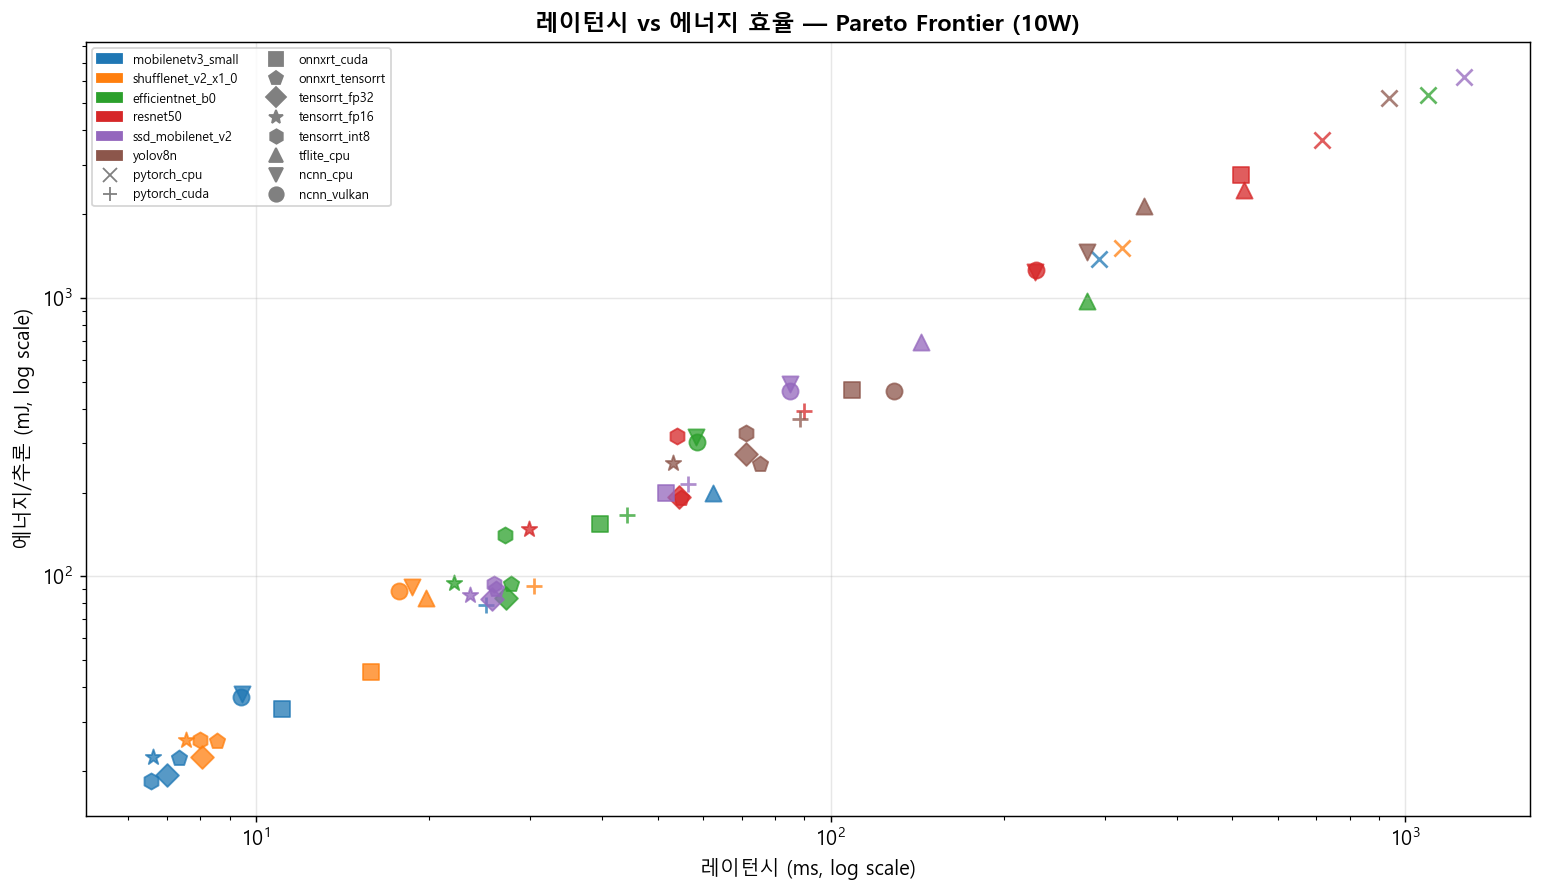

저장: results/pareto_frontier.png


In [25]:
# 최종 요약 시각화
fig, ax = plt.subplots(figsize=(12, 7))

valid_plot = valid[valid['energy_per_inference_mj']>0].copy()

model_colors_all = {
    'mobilenetv3_small': '#1f77b4', 'shufflenet_v2_x1_0': '#ff7f0e',
    'efficientnet_b0': '#2ca02c',   'resnet50': '#d62728',
    'ssd_mobilenet_v2': '#9467bd',  'yolov8n': '#8c564b'
}
rt_markers = {
    'pytorch_cpu': 'x',    'pytorch_cuda': '+',
    'onnxrt_cuda': 's',    'onnxrt_tensorrt': 'p',
    'tensorrt_fp32': 'D',  'tensorrt_fp16': '*', 'tensorrt_int8': 'h',
    'tflite_cpu': '^',     'ncnn_cpu': 'v',      'ncnn_vulkan': 'o'
}

for _, row in valid_plot.iterrows():
    color  = model_colors_all.get(row['model'], '#333')
    marker = rt_markers.get(row['runtime'], 'o')
    ax.scatter(row['latency_mean_ms'], row['energy_per_inference_mj'],
               color=color, marker=marker, s=80, alpha=0.75)

# Pareto frontier
pts = valid_plot[['latency_mean_ms','energy_per_inference_mj']].values
pareto = []
for i, p in enumerate(pts):
    if not any((pts[j,0]<=p[0] and pts[j,1]<=p[1] and (pts[j,0]<p[0] or pts[j,1]<p[1]))
               for j in range(len(pts)) if j!=i):
        pareto.append(i)
pareto_pts = pts[pareto]
pareto_pts = pareto_pts[pareto_pts[:,0].argsort()]
ax.plot(pareto_pts[:,0], pareto_pts[:,1], 'k--', alpha=0.4, linewidth=1.5, label='Pareto Frontier')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('레이턴시 (ms, log scale)')
ax.set_ylabel('에너지/추론 (mJ, log scale)')
ax.set_title('레이턴시 vs 에너지 효율 — Pareto Frontier (10W)', fontsize=13, fontweight='bold')

model_patches  = [mpatches.Patch(color=v, label=k) for k,v in model_colors_all.items()]
rt_legend = [plt.Line2D([0],[0], marker=v, color='gray', linestyle='None', markersize=8, label=k)
             for k,v in rt_markers.items()]
ax.legend(handles=model_patches + rt_legend, fontsize=7, ncol=2, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/pareto_frontier.png', bbox_inches='tight')
plt.show()
print('저장: results/pareto_frontier.png')

---
## 최종 인사이트 요약

### 1. 아키텍처가 성능의 상한선을 결정한다
아무리 런타임을 최적화해도 ResNet-50은 MobileNetV3보다 느리다. 입력 해상도(640² vs 224²)와 파라미터 수(25.6M vs 2.5M)가 만드는 연산량 차이는 런타임이 극복할 수 없다.

### 2. TRT FP16이 엣지 AI의 현실적 Sweet Spot
속도·정확도·에너지 세 축에서 동시에 최선에 가깝다. INT8은 분류 모델에서 유효하지만, 검출 모델(YOLOv8n)에서 PTQ만으로는 정확도가 붕괴한다.

### 3. 전력 모드 선택은 단순하지 않다
5W = 친환경이라는 상식이 틀렸다. CPU 의존 런타임에서는 5W가 오히려 에너지를 더 쓴다. 진짜 에너지 절감을 원하면 GPU 가속 런타임 + 10W가 더 유리하다.

### 4. 모델 크기와 속도의 상관관계는 단순하지 않다
YOLOv8n(3.2M)은 ResNet-50(25.6M)보다 파라미터가 8배 적지만, 640² 입력으로 인해 더 느릴 수 있다. 파라미터 수보다 입력 해상도와 FLOPs가 실제 추론 시간의 더 직접적인 지표다.